# Lab 5 — Spatial Filtering: Smoothing and Sharpening
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers:
1. The example from the lab manual — **Unsharp Masking**
2. The three assessment tasks — Box filter, Gaussian filters, Laplacian sharpening
3. Extra related questions — all solved



## Setup — Import libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

---
## Theory — What is spatial filtering?

**Spatial filtering** means modifying a pixel's value based on the pixels around it. You slide a small matrix called a **kernel** (or mask/filter) across the image and at each position perform a mathematical operation — usually a weighted sum. This is called **convolution**.

$$g(x,y) = \sum_{i}\sum_{j} \, K(i,j) \cdot f(x+i,\, y+j)$$

Different kernels achieve different effects:

| Goal | Kernel type | Examples in this lab |
|---|---|---|
| **Smoothing** (blur, noise removal) | Low-pass filter | Box filter, Gaussian filter |
| **Sharpening** (enhance edges) | High-pass filter | Laplacian, Unsharp Masking |

- **Low-pass** filters keep slow changes (smooth regions), block fast changes (edges, noise) → image becomes blurrier.
- **High-pass** filters do the opposite — they emphasize edges and fine detail → image becomes sharper.


## Task 1 — Unsharp Masking (from the lab manual)

**Unsharp masking** is a classic sharpening trick. Despite its confusing name, the output is a *sharper* image. The idea:

1. Blur the image → this is the "unsharp" version.
2. Subtract blurred from original → what remains are the **edges and fine details** (called the "mask").
3. Add that mask back to the original, multiplied by a gain `amount` → edges become emphasized.

**Formula:**

$$\text{sharp} = \text{original} + \text{amount} \times (\text{original} - \text{blurred})$$

**Parameters:**
- `sigma` — how strong the blur is. Larger `sigma` → wider edges are enhanced.
- `amount` — how much sharpening to apply. Typical: 0.5–2.0. Too high = unnatural "halo" artifacts.

> **Why float32?** Subtraction can produce negative numbers, and enhancement can exceed 255 — both break `uint8`. We work in float `[0, 1]` and clip at the end.

In [ ]:
# --- Code from the lab manual ---

image = data.astronaut()                                   # substitute: RGB color image

# Gaussian sigma (blur strength)
sigma = 2

# Sharpening strength
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

## What Does the "Mask" in Unsharp Masking Look Like?
Unsharp masking = `original + amount × (original − blurred)`.

The term `(original − blurred)` is the **mask** — it's literally the high-frequency detail (edges and textures). 

In [ ]:
img = data.astronaut().astype(np.float32) / 255.0
blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=2)
mask = img - blurred                       # high-frequency detail

# Shift the mask so it's visible (it has negative values around 0)
mask_display = (mask - mask.min()) / (mask.max() - mask.min())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img);          ax[0].set_title("Original");                    ax[0].axis("off")
ax[1].imshow(blurred);      ax[1].set_title("Blurred (low-frequency part)");ax[1].axis("off")
ax[2].imshow(mask_display); ax[2].set_title("Mask (high-frequency part)");  ax[2].axis("off")
plt.tight_layout(); plt.show()

---


## Assessment Task 1 — 7×7 Box Filter

A **box filter** is the simplest smoothing filter: every pixel is replaced by the **average** of the pixels in a square window around it. Every weight is equal — like a blurred "box" of influence.

A 7×7 box kernel looks like:

$$K = \frac{1}{49}\begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

All 49 entries are `1/49` so the weights sum to 1 (preserves average brightness).

**Effect:** Blurs the image and reduces noise. Downside: also blurs edges and produces slightly "blocky" results because of the equal weights.

Steps: 
1) Build the kernel manually.
2) Apply convolution. `cv2.filter2D` is the general-purpose convolution function. It takes any kernel you give it and slides it across the image.


In [ ]:
img = data.astronaut()

# Method 1: build the kernel manually and convolve with filter2D
kernel = np.ones((7, 7), dtype=np.float32) / 49

smoothed_manual = cv2.filter2D(img, ddepth= -1, kernel=kernel)

# cv2.blur is a built-in function that does the same thing

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img);             ax[0].set_title("Original");            ax[0].axis("off")
ax[1].imshow(smoothed_manual); ax[1].set_title("7×7 Box Filter");      ax[1].axis("off")
plt.tight_layout(); plt.show()

## Assessment Task 2 — 5×5 and 21×21 Gaussian Filters

The **Gaussian filter** is a smarter blur than the box filter. Instead of giving all pixels equal weight, it weights **nearby pixels more** than far ones, following a 2D Gaussian (bell-curve) distribution:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A 5×5 Gaussian kernel (small blur):

$$\frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$

**Why prefer Gaussian over box?**
- Smoother, more natural-looking blur (no blocky artifacts)
- Preserves edges slightly better for the same blur strength
- It's the mathematically optimal tradeoff between blurring and detail preservation

**Kernel size matters:**
- Small (e.g. 5×5) → gentle blur, subtle noise reduction
- Large (e.g. 21×21) → heavy blur, washes out fine detail

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread('image.jpg')

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply 5x5 Gaussian Filter
gaussian_5x5 = cv2.GaussianBlur(image_rgb, (5, 5), 0)

# Apply 21x21 Gaussian Filter
gaussian_21x21 = cv2.GaussianBlur(image_rgb, (21, 21), 0)

# Display results
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

# 5x5 Gaussian Filter
plt.subplot(1, 3, 2)
plt.imshow(gaussian_5x5)
plt.title('5x5 Gaussian Filter')
plt.axis('off')

# 21x21 Gaussian Filter
plt.subplot(1, 3, 3)
plt.imshow(gaussian_21x21)
plt.title('21x21 Gaussian Filter')
plt.axis('off')

plt.show()

## Assessment Task 3 — 3×3 Laplacian Sharpening

The **Laplacian** is a *second-order* derivative operator that responds to rapid intensity changes (edges) from any direction. A common 3×3 Laplacian kernel:

$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The Laplacian's raw output is **negative around bright edges and positive around dark ones**. By itself it doesn't look like an image — it looks like an edge map.

**Sharpening trick:**

$$\text{sharp} = \text{original} - \text{laplacian}$$

Subtracting the Laplacian from the original boosts edges. The result: the image looks the same, but edges pop more.

Steps (exactly as requested in the lab):
1. Read the image
2. Convert to `float32` (Laplacian can produce negatives)
3. Apply `cv2.Laplacian()`
4. Sharpen: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the three images

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image
image = cv2.imread('image.jpg')

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Convert to float32 and normalize
image_float = image_rgb.astype(np.float32) / 255.0

# 3. Apply Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F)

# 4. Sharpen image
sharp = np.clip(image_float - laplacian, 0, 1)

# 5. Plot results
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_float)
plt.title('Original Image')
plt.axis('off')

# Laplacian Output
plt.subplot(1, 3, 2)
plt.imshow(np.clip(laplacian + 0.5, 0, 1))
plt.title('Laplacian')
plt.axis('off')

# Sharpened Image
plt.subplot(1, 3, 3)
plt.imshow(sharp)
plt.title('Sharpened Image')
plt.axis('off')

plt.show()

## Q1 — Effect of Different Box Filter Sizes
Compare 3×3, 9×9, and 15×15 box filters. Bigger kernel = stronger blur = more detail lost.

In [ ]:
img = data.astronaut()

sizes = [3, 9, 15]
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
for i, k in enumerate(sizes, start=1):
    blurred = cv2.blur(img, (k, k))
    ax[i].imshow(blurred); ax[i].set_title(f"{k}×{k} box"); ax[i].axis("off")
plt.tight_layout(); plt.show()

## Q2 — Median Filter: Removing Salt-and-Pepper Noise
The **median filter** replaces each pixel with the *median* of its neighborhood — not the mean. It's the best tool for removing "salt and pepper" noise (random black and white specks), because the median ignores extreme outliers.

Compare the median filter to a Gaussian blur on the same noisy image — Gaussian smears the specks, median removes them cleanly.

In [ ]:
img = data.astronaut()

# Manually add salt-and-pepper noise
np.random.seed(42)
noisy = img.copy()
n = 8000
ys = np.random.randint(0, img.shape[0], n)
xs = np.random.randint(0, img.shape[1], n)
noisy[ys[:n//2], xs[:n//2]] = 0       # pepper (black)
noisy[ys[n//2:], xs[n//2:]] = 255     # salt (white)

# Clean with two different filters for comparison
gaussian_cleaned = cv2.GaussianBlur(noisy, (3, 3), sigmaX=0.5)
median_cleaned = cv2.medianBlur(noisy, 3)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(noisy);           ax[0].set_title("Noisy");             ax[0].axis("off")
ax[1].imshow(gaussian_cleaned);ax[1].set_title("Gaussian blur");     ax[1].axis("off")
ax[2].imshow(median_cleaned);  ax[2].set_title("Median filter ✓"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp
A normal Gaussian blur smooths everything — including edges. The **bilateral filter** is smarter: it blurs pixels only if they are close in *space* AND similar in *intensity*. Result: flat areas get smoothed, but edges stay crisp. Used in "beauty" filters, cartoon effects, and denoising.

In [ ]:
img = data.astronaut()

gauss_blur      = cv2.GaussianBlur(img, (9, 9), 0)
bilateral_blur  = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img);            ax[0].set_title("Original");           ax[0].axis("off")
ax[1].imshow(gauss_blur);     ax[1].set_title("Gaussian (edges blurred)"); ax[1].axis("off")
ax[2].imshow(bilateral_blur); ax[2].set_title("Bilateral (edges preserved)"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## Q6 — Compare All Smoothing Filters on the Same Image
One picture is worth a thousand words — put Box, Gaussian, Median, and Bilateral side by side.

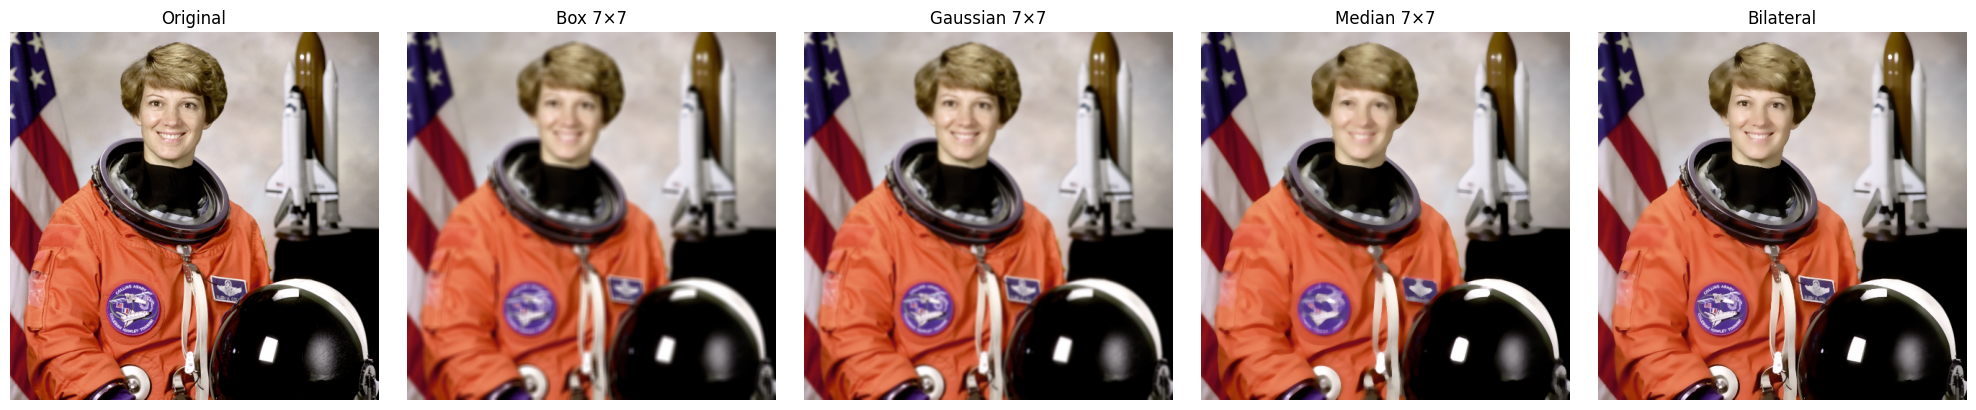

---
## Summary Table

| Filter | Type | Effect | OpenCV function |
|---|---|---|---|
| **Box** | Smoothing (low-pass) | Simple average blur | `cv2.blur` or `cv2.filter2D` |
| **Gaussian** | Smoothing (low-pass) | Bell-curve weighted blur, smoother | `cv2.GaussianBlur` |
| **Median** | Smoothing (non-linear) | Removes salt-and-pepper noise | `cv2.medianBlur` |
| **Bilateral** | Smoothing (edge-preserving) | Blurs flat areas, keeps edges | `cv2.bilateralFilter` |
| **Laplacian** | Sharpening (high-pass) | Second-derivative edge enhance | `cv2.Laplacian` |
| **Unsharp mask** | Sharpening (combo) | Original + (original − blurred) | Custom (using `cv2.GaussianBlur`) |
| **Custom kernel** | Anything | Any effect you design | `cv2.filter2D` |

**Two rules to remember:**
1. For *smoothing* → use a low-pass filter (Box, Gaussian, Median, Bilateral).
2. For *sharpening* → amplify the high-frequency content (Laplacian, Unsharp mask, custom kernel with negative surround).

**End of notebook.**